# 'Skeleton' Utils

In [1]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from natsort import natsorted
import re
import csv
import seaborn as sns

## Max Projection
For max projection z projection check code/imutils/dev

In [ ]:
##Compare different Behavioural recordings:

### Delete Files with a specific string in directory 
Always run it with #os.remove commented first!

In [ ]:
main_path='/Volumes/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/datasets/'

for roots, dirs, files in natsorted(os.walk(main_path)):
    for single_dir in dirs:
        for single_file in natsorted(files):
#            print((os.path.join(roots,single_dir,single_file)))
            #print(files)
            if 'compressed' in single_file and 'ome.tif' not in single_file:
                print(os.path.join(roots, single_file))
                #os.remove(os.path.join(roots, single_file))
                #break

### Tiff Writer example

In [ ]:
with tiff.TiffWriter(output_filename, bigtiff=True) as tif_writer:
    for img in video:
        tif_writer.save(img, photometric='minisblack', description=omexmlMetadataString)

## CSV Reader example

In [5]:
import csv
import numpy as np
csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/centerlines/filename.csv'

# open file in read mode
with open(csv_path, 'r') as read_obj:
    # pass the file object to reader() to get the reader object
    csv_reader = csv.reader(read_obj)
    # Iterate over each row in the csv using reader object
    for row in csv_reader:
        # row variable is a list that represents a row in csv
        print(row)
        #do this to convert to array:
        #array=np.asarray(row, dtype=np.float64)
print('\nto convert to array uncomment last line')

['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img038208.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img038227.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img038247.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img038272.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img038274.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img038414.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img038434.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img188775.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img189209.tif']
['labeled-data/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/img189271.tif']

to convert to array uncomment last line


## CSV Writer example

In [18]:
#file=open("second_derivative.csv", K)
import csv
csvfile=open('persons.csv','w', newline='')
csv_writer=csv.writer(csvfile)
csv_writer.writerow('hello')
csvfile.close()

In [ ]:
import csv
import numpy as np
persons=[('Lata',22,45),('Anil',21,56),('John',20,60)]
K=np.ones(10)
csvfile=open('personsK.csv','w', newline='')
csv_writer=csv.writer(csvfile)
for person in persons:
    csv_writer.writerow(K)
csvfile.close()

### OPENCV reader and writer example

In [ ]:
#Load input .avi and create output .avi
#video reader
file_path='/scratch/zimmer/Ulises_temp/GCAMP7/matlab_analysis/als_files/avi/2020-09-21_15-55-38_lite1_2_MMStack_1.avi'
#file_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_btf/2020-06-05_16-46-41_worm1-channel-0-bigtiff.btf'
video_cap = cv2.VideoCapture(file_path)
#video writer
fps=10 #fps = video_cap.get(cv2.CAP_PROP_FPS)
frame_width = int(video_cap.get(3))
print('frame width is: '+str(frame_width))
frame_height = int(video_cap.get(4))
print('frame height is: '+str(frame_height))
output_filepath='/scratch/zimmer/Ulises_temp/GCAMP7/matlab_analysis/als_files/avi/2020-09-21_15-55-38_lite1_2_MMStack_1_compressed.avi'
video_out = cv2.VideoWriter(output_filepath,cv2.VideoWriter_fourcc('M','J','P','G'), fps, (frame_width,frame_height))
k=0
while(video_cap.isOpened()):
    ret,frame=video_cap.read()
    if ret == True:
        output=frame.copy()
        video_out.write(output)
        k=k+1
    #if k>0:
        #video_cap.release()
    else:
        video_cap.release()
        #video_out.release()
        #cv2.destroyAllWindows()

### Tiff reader (Multi)

In [ ]:
input_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/20201111/2020-11-11_10-51-56_control_worm1-channel-0-/2020-11-11_10-51-56_control_worm1-channel-0-_MMStack.ome.tif'
output_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/20201111/2020-11-11_10-51-56_control_worm1-channel-0-/2020-11-11_10-51-56_control_worm1-channel-0-_BigTiff.btf'

with tiff.TiffWriter(output_filepath, bigtiff=True) as output_tif:
    with tiff.TiffFile(input_filepath, multifile=True) as tif:
        #for our data there would be only one series
        for page in tif.series[0].pages:
            img=page.asarray()
            output_tif.save(img, photometric='minisblack')#
            #break
            #could one liner work?    tiff.writer(tif.series[0].pages)

TiffTag 270: coercing invalid ASCII to bytes
TiffTag 270: coercing invalid ASCII to bytes
TiffTag 270: coercing invalid ASCII to bytes


### Tiff reader, CV2 writer with codecs

In [20]:
#Load input .avi and create output .avi
#video reader
#file_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_avi/2020-06-05_16-46-41_worm1-channel-0-bigtiff.avi'
#file_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_btf/2020-06-05_16-46-41_worm1-channel-0-bigtiff.btf'
#file_path='/groups/zimmer/shared_projects/Barbara_Ulises/2020/Code/Example/Recording/2020-08-13_16-03-41_zim2051_dlc_ma_10fps_all_MMStack.ome.btf'
file_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_btf/2020-07-01_14-41-11_chemotaxisl_worm2-channel-0-bigtiff.btf'
#video writer
fps=167
frame_width = 608#
frame_height = 610#
#ALSO NOT WORKKING: , FRWA, FRWD, IRAW, LAGS, LCW2, PIMJ, ASLC "-1",
output_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_avis/2020-07-01_14-41-11_chemotaxisl_worm2-channel-0-bigtiff.avi'
fourcc=0
video_out = cv2.VideoWriter(output_filepath, fourcc=fourcc, fps=fps, frameSize=(frame_width,frame_height), isColor=False)

with tiff.TiffFile(file_path, multifile=False) as tif:
    #print(tif)
    for i, page in enumerate(tif.pages):
        #print(i)
        img=page.asarray()
        #img=cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
        video_out.write(img)
        #if i>20: continue
video_out.release()
#cv2.destroyAllWindows()

In [54]:
#tif2avi
import cv2
import tifffile as tiff
file_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_btf/2020-07-01_14-41-11_chemotaxisl_worm2-channel-0-bigtiff.btf'
#video writer
fps=167
frame_width = 608#
frame_height = 610#
output_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_avis/2020-07-01_14-41-11_chemotaxisl_worm2-channel-0-bigtiff.avi'
#ALSO NOT WORKKING: , FRWA, FRWD, IRAW, LAGS, LCW2, PIMJ, ASLC "-1",
fourcc=cv2.VideoWriter_fourcc(*'MJPG')

with tiff.TiffFile(file_path, multifile=False) as tif:
    print(tif)
    frameSize=tif.pages[0].shape
    frame_height, frame_width=tif.pages[0].shape
    video_out = cv2.VideoWriter(output_filepath, apiPreference=0, fourcc=fourcc, fps=fps, frameSize=(frame_width,frame_height), isColor=False)

    for i, page in enumerate(tif.pages):
        print(i)
        img=page.asarray()
        #img=cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
        video_out.write(img)
        if i>200: break
video_out.release()
#cv2.destroyAllWindows()

TiffFile '2020-07…tiff.btf'  69.13 GiB  BigTiff  shaped  200001 Pages  2 Series
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201


In [43]:
print(*'MJPG')
print('MJPG')
print(type(*'0'))
cv2.VideoWriter_fourcc('M','J','P','G')

M J P G
MJPG
<class 'str'>


In [ ]:
#visualize data (for worm length on beh zim01)

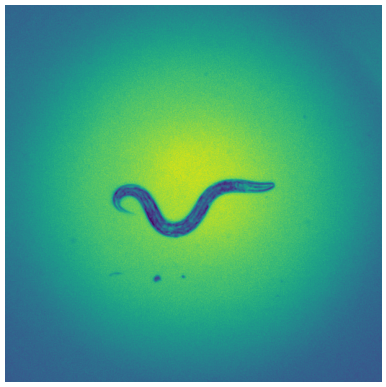

In [27]:
file_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_btf/2020-07-01_17-32-12_control_worm4-channel-0-bigtiff.btf'
with tiff.TiffFile(file_path, multifile=False) as tif:
    #print(tif)
    for i, page in enumerate(tif.pages):
        if i%1000==0:continue

        if i==1001: break
img=page.asarray()
fig, ax=plt.subplots(figsize=(10,10), dpi=50)
ax.imshow(img)
ax.set_axis_off()

/users/ulises.rey/anaconda3/envs/openCV/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  from ipykernel import kernelapp as app


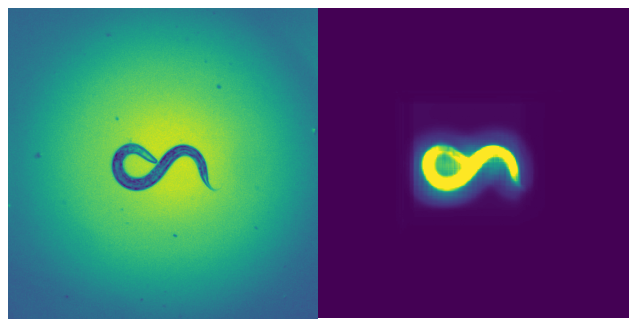

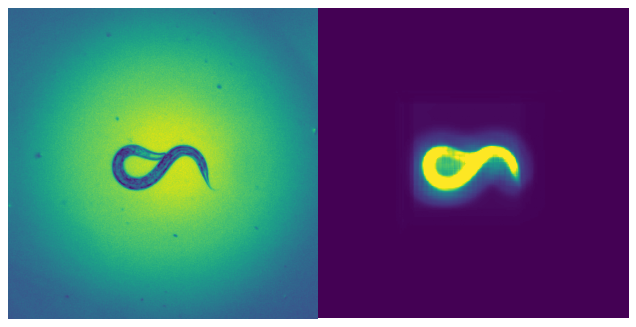

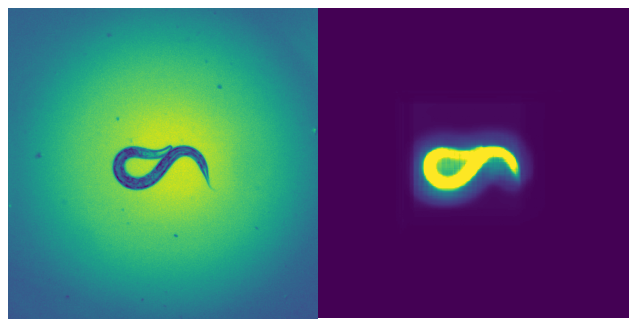

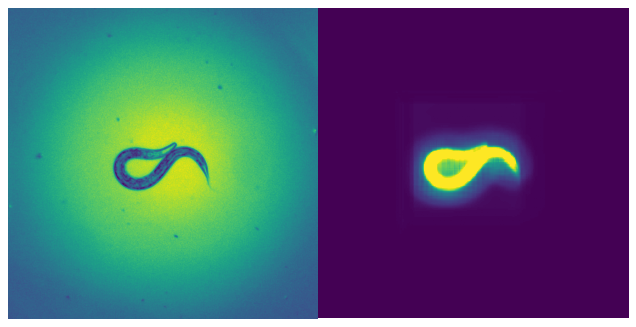

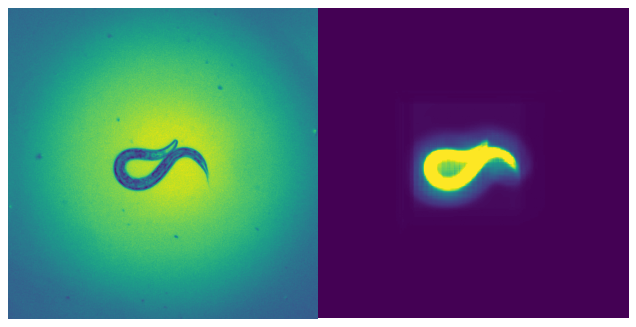

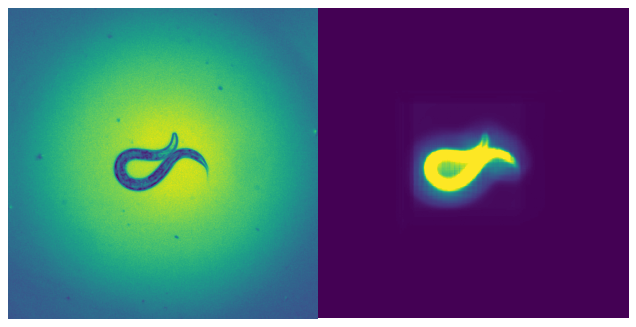

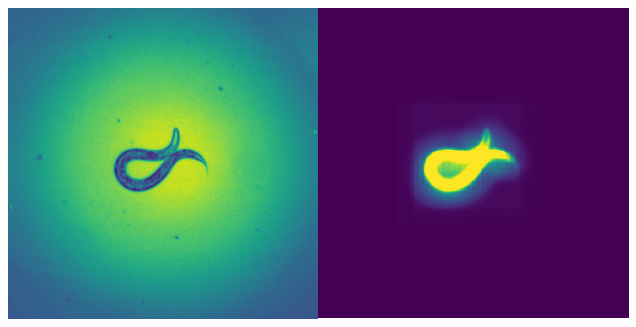

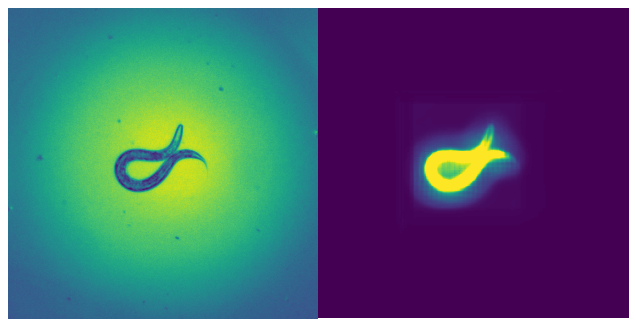

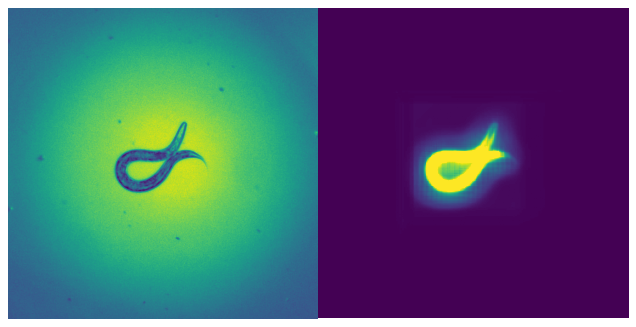

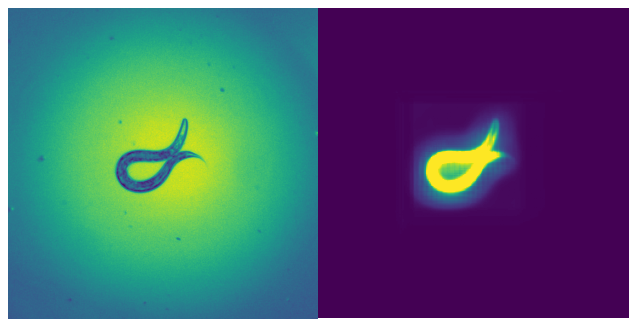

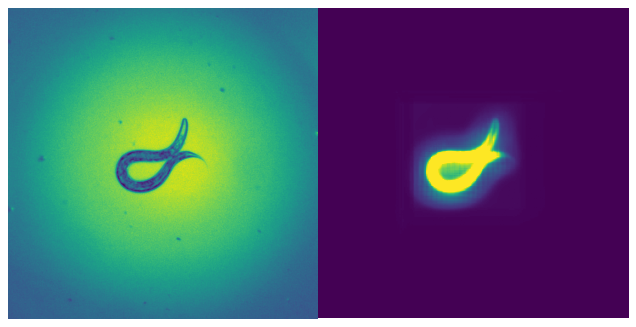

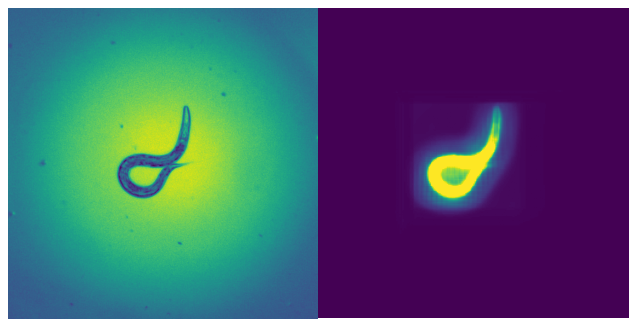

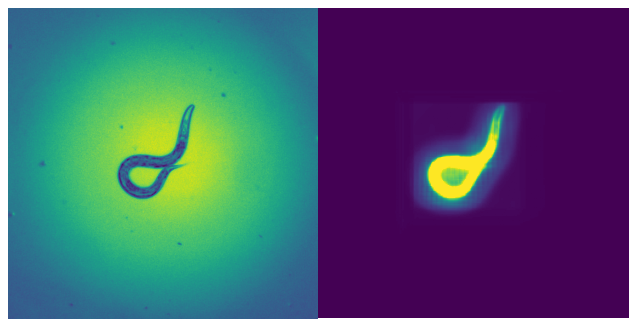

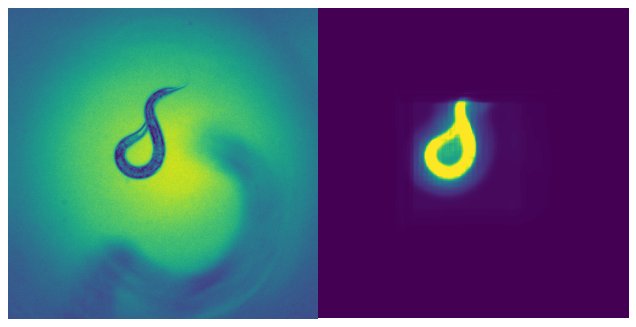

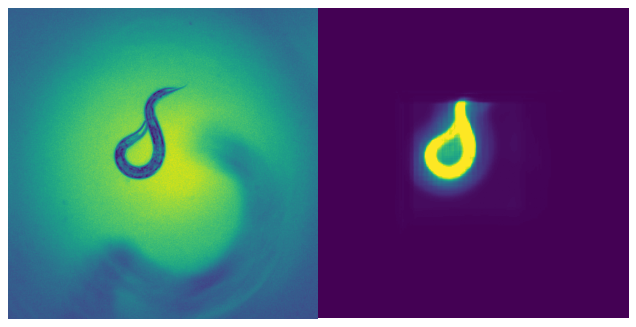

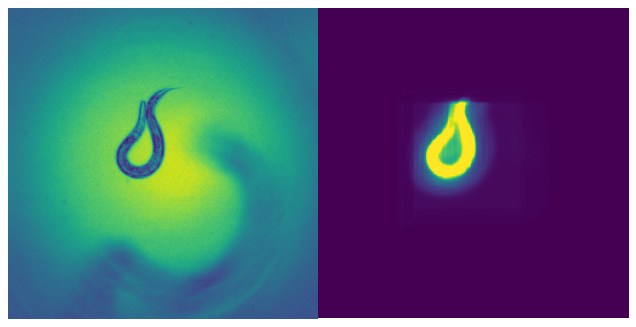

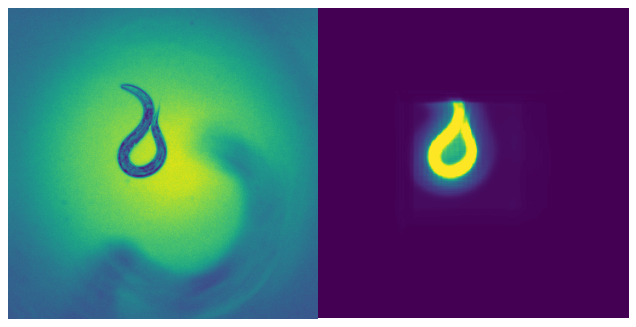

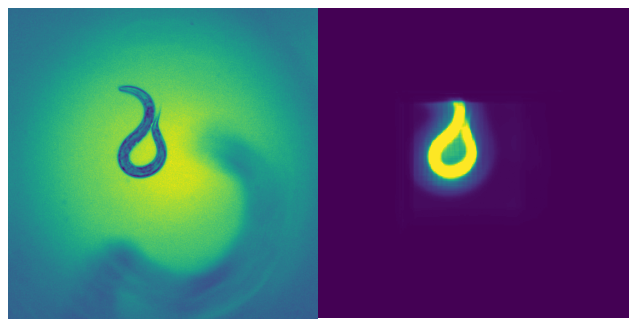

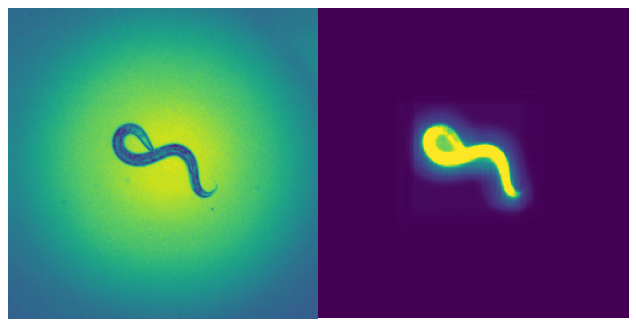

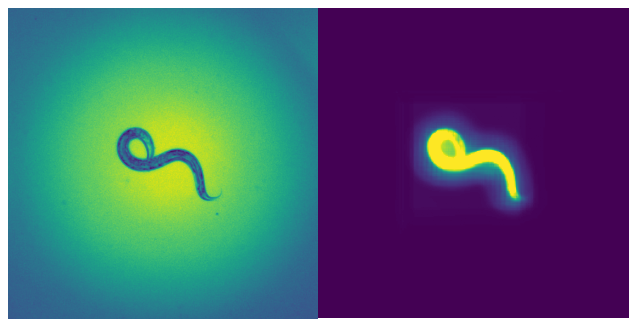

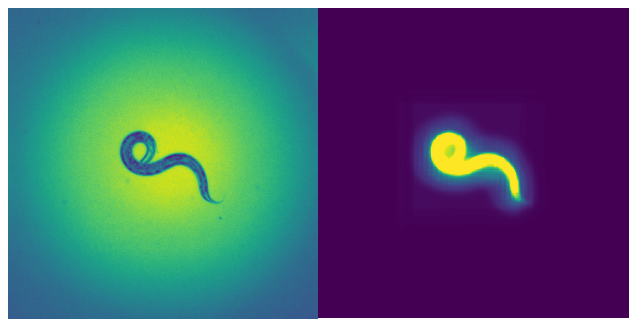

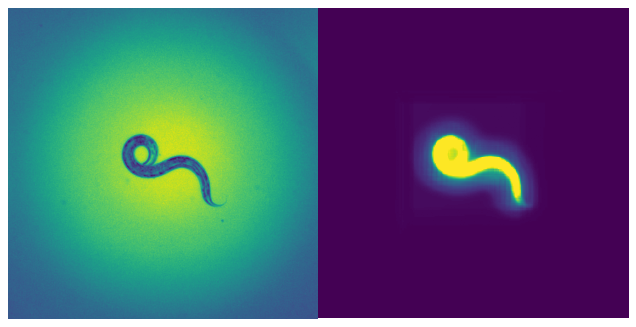

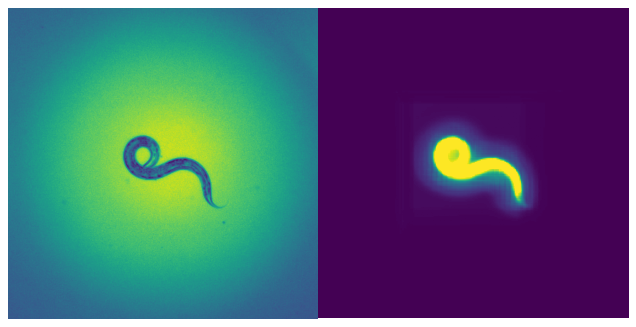

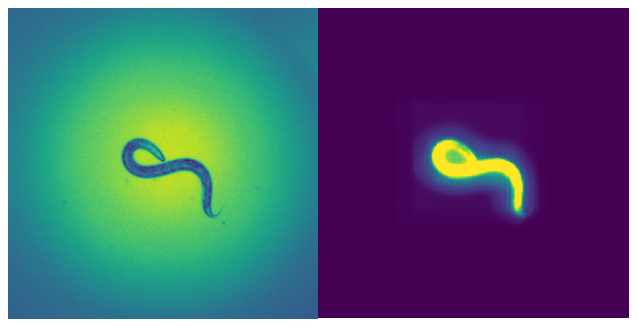

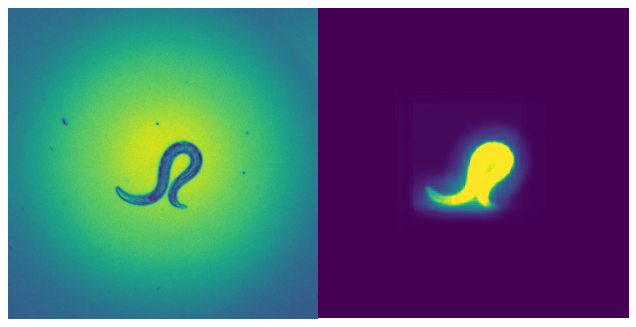

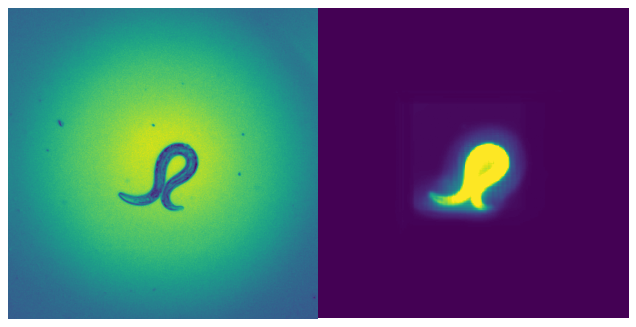

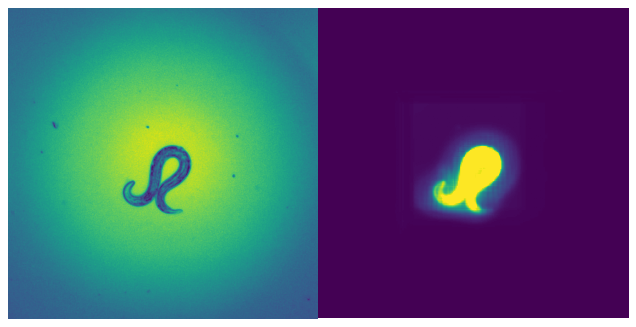

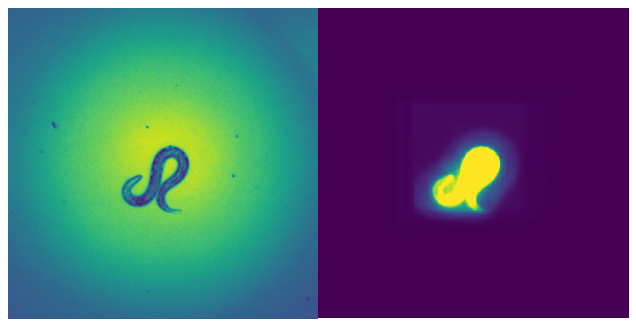

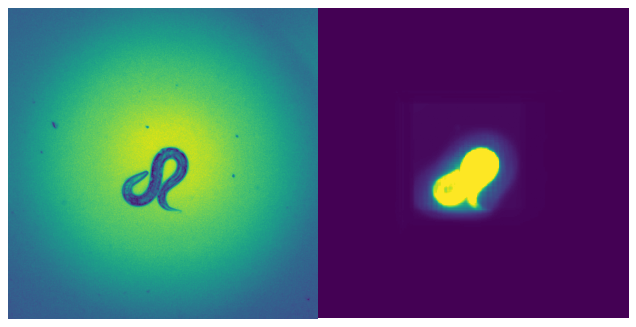

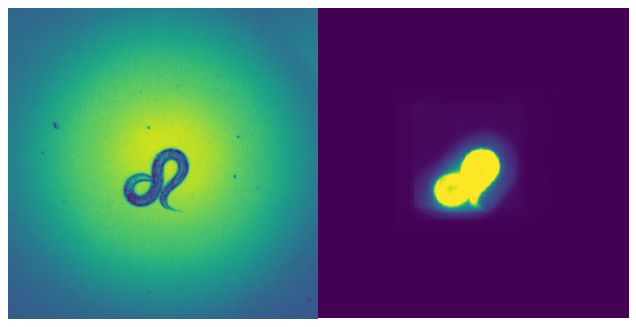

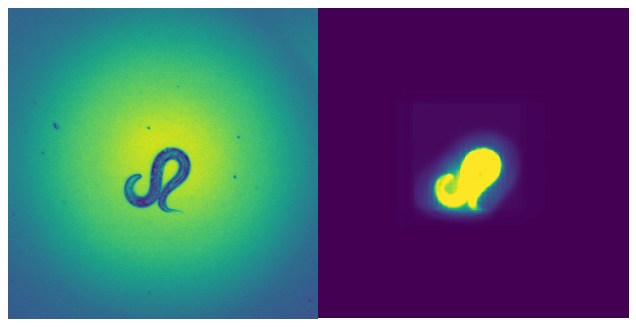

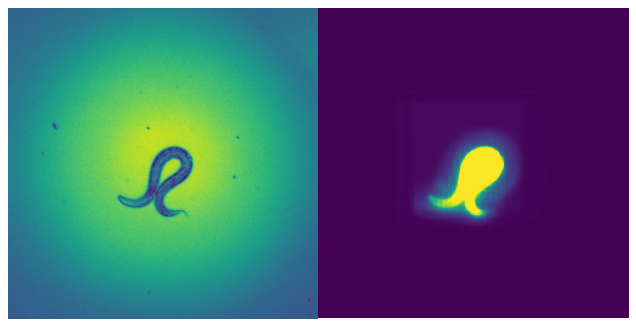

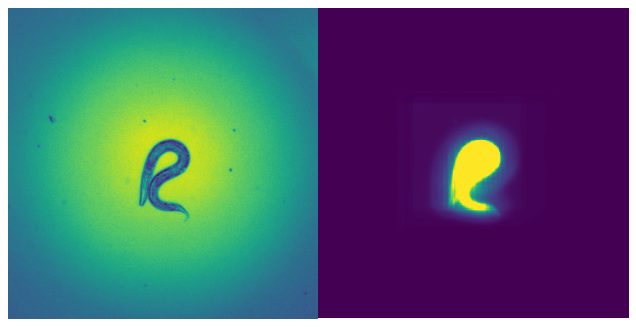

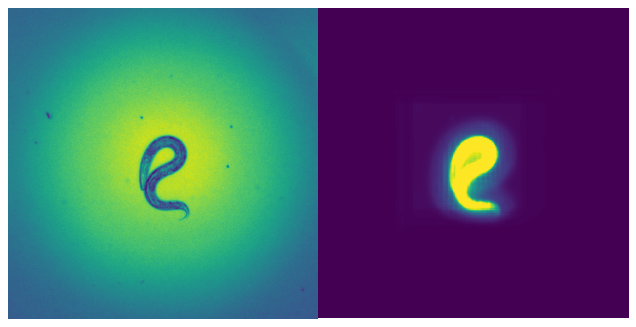

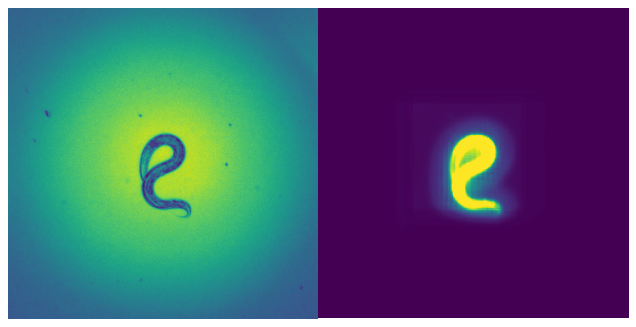

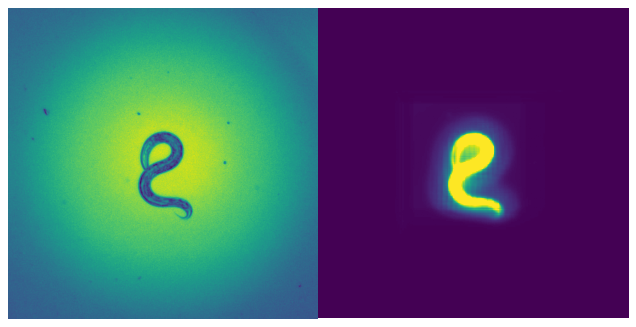

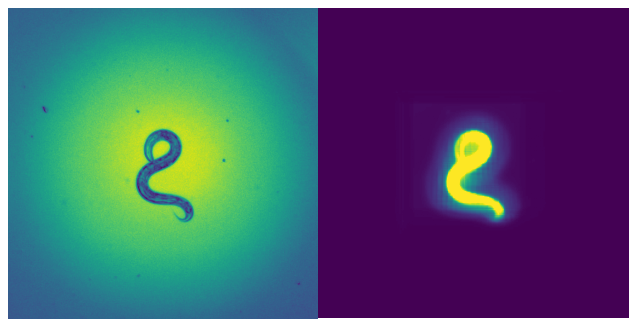

In [36]:
#visualize and comapre two images with same name but in different folders?
path='/groups/zimmer/Ulises/code/unet-master/data/worm_nb/test_inputs//'
s_path='/groups/zimmer/Ulises/code/unet-master/data/worm_nb/test_results/'



for i, filename in enumerate(natsorted(os.listdir(path))):
    #if i%6!=0:continue
    
    img=cv2.imread(os.path.join(path,filename),0)
    
    #s_img=cv2.imread(os.path.join(s_path, filename),0)
    s_img=cv2.imread(os.path.join(s_path,natsorted(os.listdir(s_path))[i]),0)
                     
    fig, axes=plt.subplots(nrows=1, ncols=2,figsize=(10,10), dpi=80)#65#80
    fig.subplots_adjust(wspace=0, hspace=0)
    axes[0].imshow(img),# vmin=100, vmax=255)
    axes[1].imshow(s_img)#, vmin=150, vmax=255)
    for ax in axes:
        #ax.set_xlim(100, 500)
        #ax.set_ylim(100, 500)
        ax.axis('off')

(256, 256)


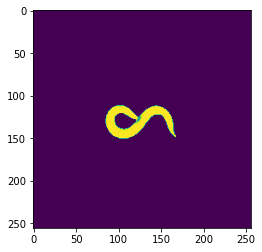

In [17]:
print(s_img.shape)
plt.imshow(s_img)

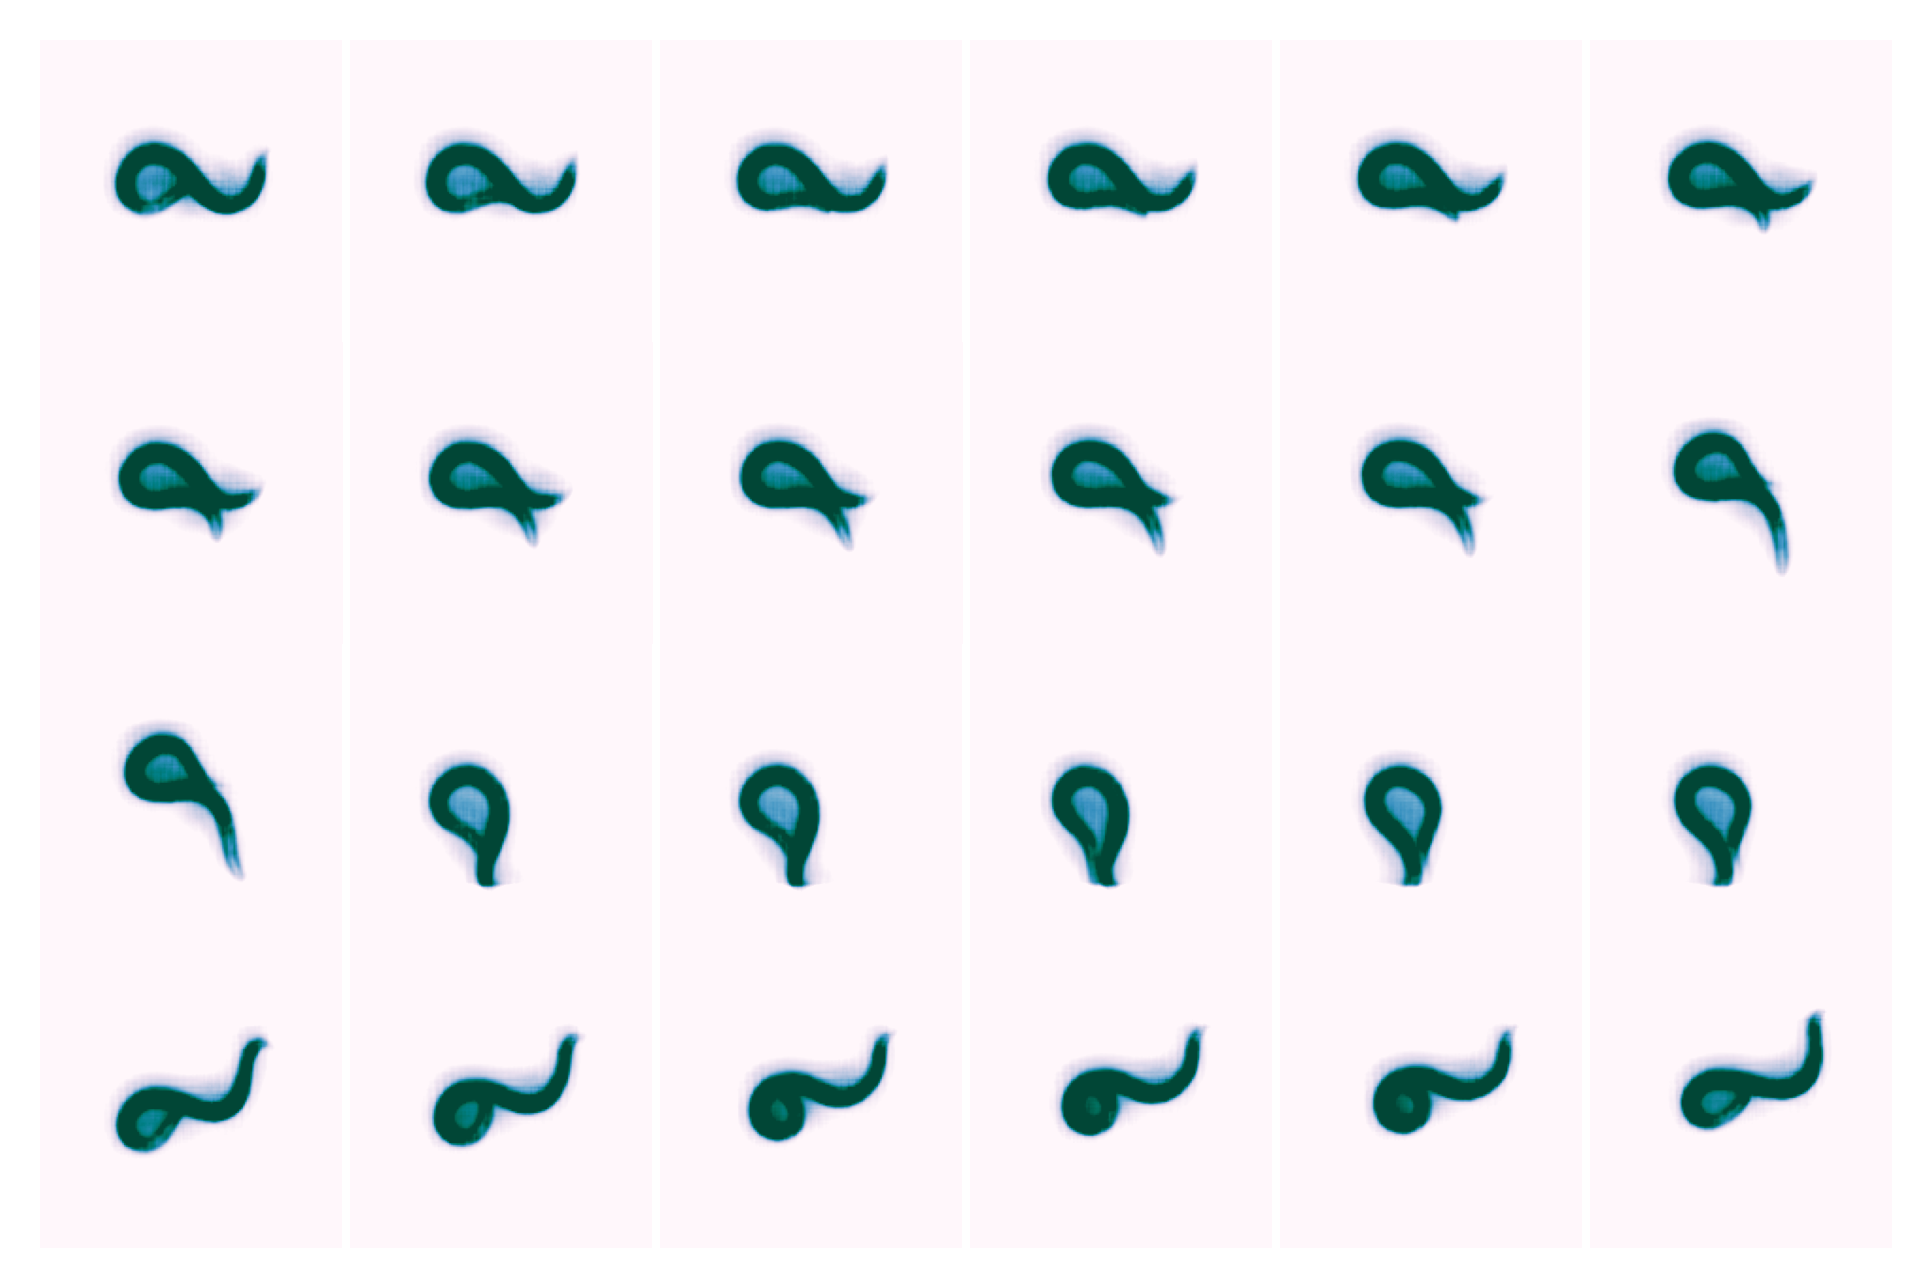

In [57]:
#visualize many images
path='/groups/zimmer/Ulises/code/unet-master/data/worm_nb/test_results/'

nrows=4
ncols=6
fig, axes=plt.subplots(nrows=nrows, ncols=ncols,figsize=(6,4), dpi=400)#65#80
fig.subplots_adjust(wspace=0, hspace=0)

filename=natsorted(os.listdir(path))
i=0
for r in np.arange(nrows):
    for c in np.arange(ncols):
        img=cv2.imread(os.path.join(path,filename[i]),0)
        #img=np.bitwise_not(img)
        i=i+1
        axes[r,c].imshow(img, cmap='PuBuGn', vmin=25)   
        #print(type(ax))
        #print((ax.shape))
        #axes[r,c].imshow(img),# vmin=100, vmax=255)
        axes[r,c].set_xlim(45, 205)
        axes[r,c].set_ylim(45, 205)
        axes[r,c].axis('off')

In [19]:
type(filename[1])

str

In [22]:
os.path.join(path,filename[0])

'/groups/zimmer/Ulises/code/unet-master/data/worm_nb/test_inputs/img38048.tiff'

In [16]:
for i,(r,c) in enumerate(zip(np.arange(6), np.arange(5))):
    print(i)
    print(r,c)

0
0 0
1
1 1
2
2 2
3
3 3
4
4 4


In [ ]:
#end of visualize data

In [51]:
cv2.VideoWriter_fourcc('M','J','P','G')

1196444237

In [52]:
cv2.VideoWriter_fourcc(*'MJPG')

1196444237

In [39]:
import numpy as np
frameSize=tif.pages[0].shape
frame_height, frame_width=tif.pages[0].shape
frameSize==(frame_height, frame_width)

True

In [29]:
type(frameSize)

tuple

In [31]:
type((frame_height, frame_width))

tuple

In [18]:
import tifffile as tiff
#file_path='/groups/zimmer/shared_projects/Barbara_Ulises/2020/Code/Example/Recording/2020-08-13_16-03-41_zim2051_dlc_ma_10fps_all_MMStack.ome.tif'

file_path='/groups/zimmer/shared_projects/Barbara_Ulises/2020/Recordings/2020-08-13_16-03-41_zim2051_dlc_ma_BH2_10fps/2020-08-13_16-03-41_zim2051_dlc_ma_10fps_all_MMStack.ome.tif'

#file_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_btf/2020-06-05_16-46-41_worm1-channel-0-bigtiff.btf'
tif= tiff.TiffFile(file_path)

In [14]:
for idx, page in enumerate(tif.pages):
    print(idx)

0


(2048, 2048)
<class 'tifffile.tifffile.TiffPage'>


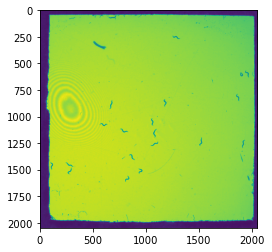

In [19]:

for i, page in enumerate(tif.pages):
    print(page.shape)
    print(type(page))
    img=page.asarray()
    #img8=img.astype(np.uint16)
    plt.imshow(img)
    plt.show()
    if i>20: break

In [ ]:
main_path='/scratch/zimmer/Ulises_temp/GCAMP7/'

for roots, dirs, files in natsorted(os.walk(main_path)):
    print(dirs)
    for single_dir in natsorted(dirs):
        print('the directory is:')
        print(os.path.join(roots,single_dir)+'\n')
        ometiff2bigtiff(os.path.join(roots,single_dir))

In [ ]:
main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/datasets/dataset_20200605/'

for roots, dirs, files in natsorted(os.walk(main_path)):
    print(dirs)
    for single_dir in natsorted(dirs):
        if 'worm' in single_dir and 'bg' not in single_dir:
            print('the directory is:')
            print(os.path.join(roots,single_dir)+'\n')
            ometiff2bigtiff(os.path.join(roots,single_dir))

### Resize ometiff file
Compress it to smaller (in dimensions) tiff file

In [ ]:
#define compress_ometif function
def compress_ometif(file):
    #print('reading ome tif file: '+file+'\n... might take a while')
    retval, mats=cv2.imreadmulti(file)
    #print('reading complete')
    ometif=np.asarray(mats)
    new_img=np.full((ometif.shape[0],200,200), 0, dtype='uint8')
    #print('entering the loop')
    for k,img in enumerate(ometif):
        resized = cv2.resize(img, (200,200), interpolation = cv2.INTER_AREA)
        new_img[k]=resized
    return new_img
    #tiff.imsave(filename,new_img, bigsize=True) 

## Draw BodyParts
Very important functions, some are inside dlc_utils, some are not.

0
[]


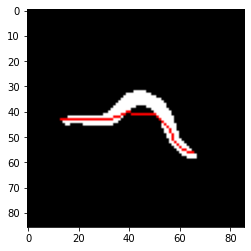

1
[0.]


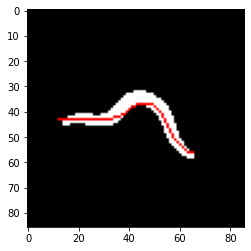

2
[0. 1.]


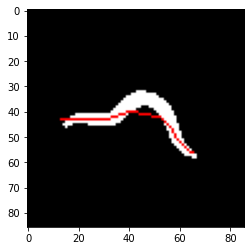

3
[0. 1. 2.]


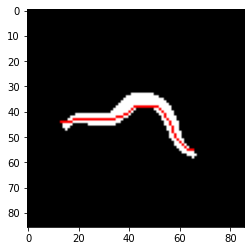

4
[0. 1. 2. 3.]


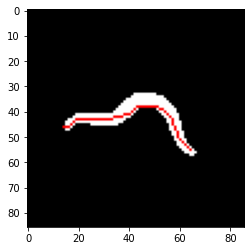

5
[0. 1. 2. 3. 4.]


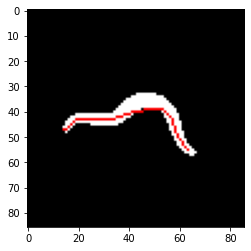

6
[0. 1. 2. 3. 4. 5.]


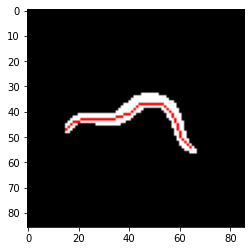

7
[0. 1. 2. 3. 4. 5. 6.]


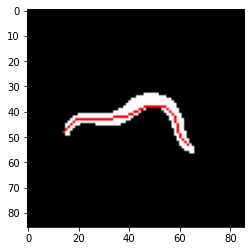

8
[0. 1. 2. 3. 4. 5. 6. 7.]


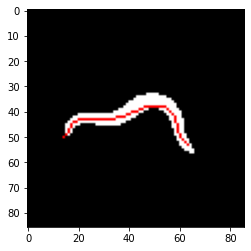

9
[0. 1. 2. 3. 4. 5. 6. 7. 8.]


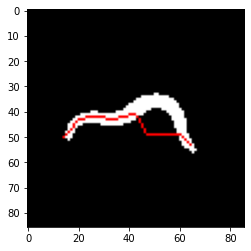

10
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


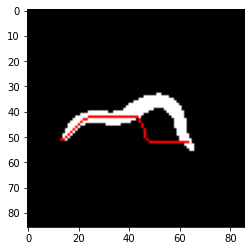

11
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


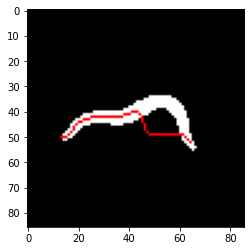

12
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]


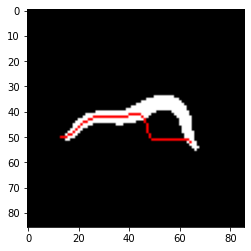

13
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]


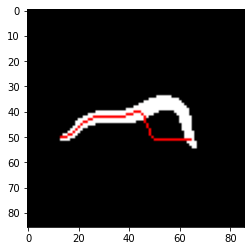

14
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.]


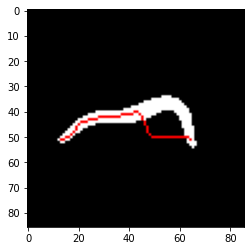

15
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]


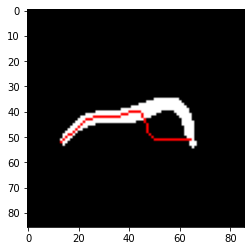

16
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


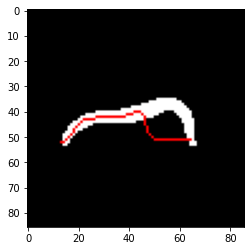

17
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16.]


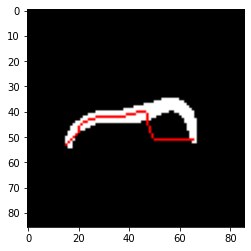

18
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.]


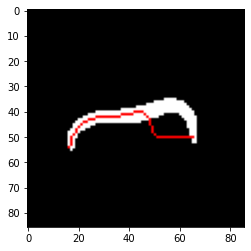

19
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18.]


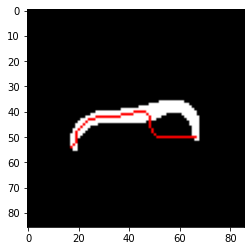

20
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]


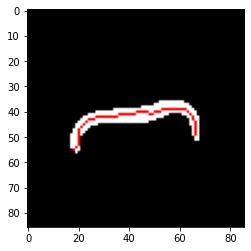

21
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20.]


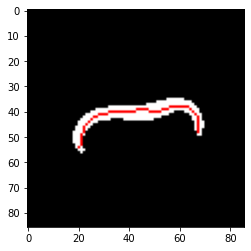

22
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21.]


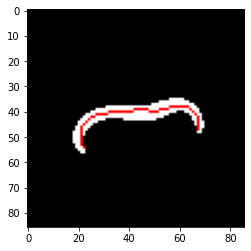

23
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22.]


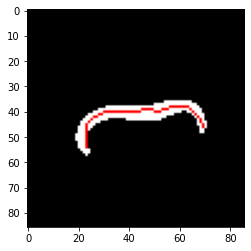

24
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23.]


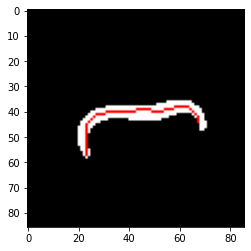

25
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24.]


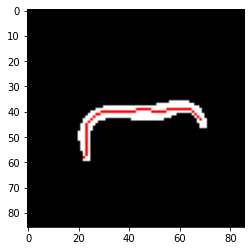

26
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]


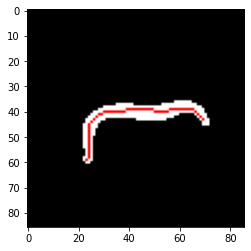

27
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26.]


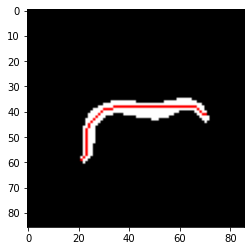

28
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27.]


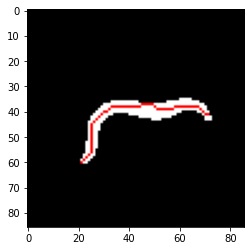

29
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28.]


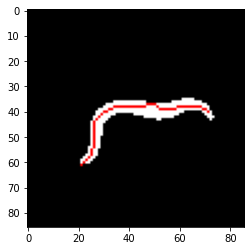

30
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]


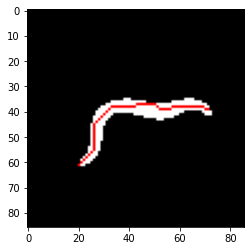

31
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]


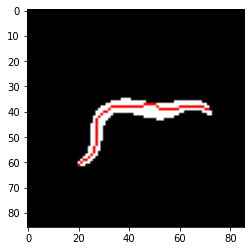

32
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31.]


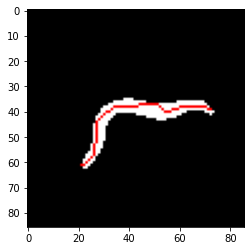

33
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32.]


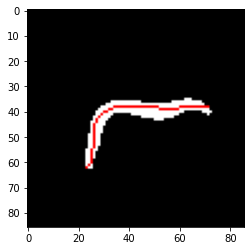

34
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33.]


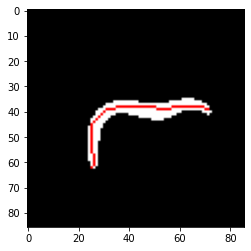

35
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34.]


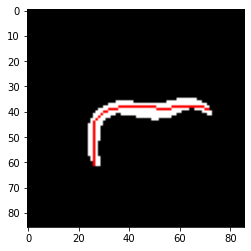

36
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.]


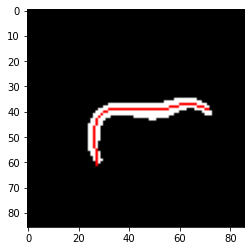

37
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36.]


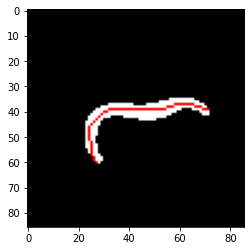

38
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37.]


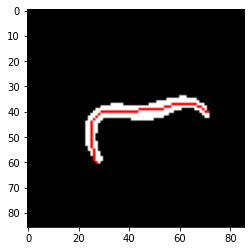

39
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38.]


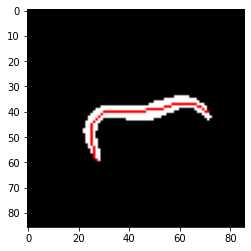

40
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39.]


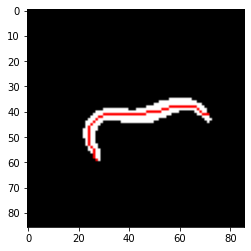

41
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40.]


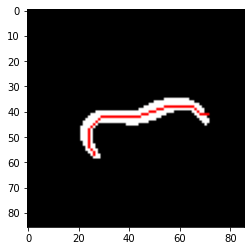

42
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41.]


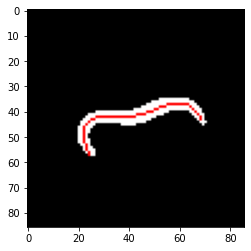

43
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42.]


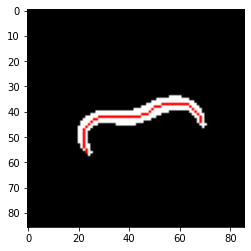

44
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43.]


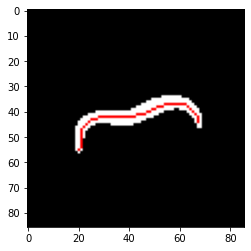

45
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44.]


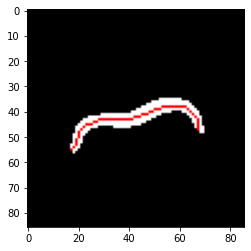

46
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45.]


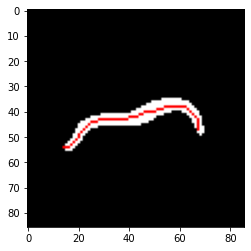

47
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46.]


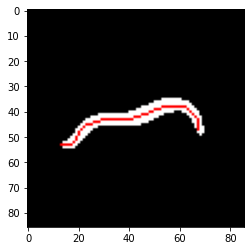

48
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47.]


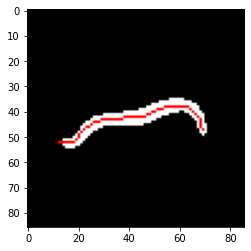

49
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48.]


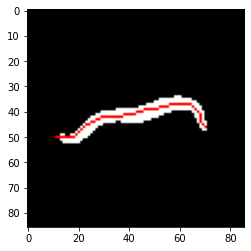

50
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49.]


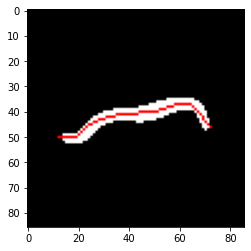

In [173]:

#pandas will not work in case every centerline has different dimensions.

# # open file in read mode
# with open(csv_pathX, 'r') as read_objX:
#     csv_readerX = csv.reader(read_objX)
#     with open(csv_pathY, 'r') as read_objY:
#         csv_readerY = csv.reader(read_objY)
        
with tiff.TiffFile(input_filename, multifile=False) as tif:
    for i, page in enumerate(tif.pages):
        print(i)
        img=page.asarray()
        #convert to BRG (3 channels)
        img=cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
        skiplist=np.linspace(0,i-1,i)
        print(skiplist)
        dfX = pd.read_csv(csv_pathX, nrows=1, skiprows=skiplist, header=None)
        dfY = pd.read_csv(csv_pathY, nrows=1, skiprows=skiplist, header=None)
        #break
        for j, x_coord in enumerate(dfX):
            #print(j)
            tuple_coords=(dfY.iloc[:,j], dfX.iloc[:,j])
            #print(type(tuple_coords))
            cv2.circle(img, tuple_coords, 0, (255,0, 0), -1)
        plt.imshow(img)
        plt.show()
        if i==50:break

                

In [ ]:
#Draw Kymograph or other coords into an image
#with objects, draw spline centerline
input_filename='/groups/zimmer/shared_projects/Barbara_Ulises/Labeller_Test/multiple_skeleton/cropped_img_worm0.tiff'

output_filename='/groups/zimmer/shared_projects/Barbara_Ulises/Labeller_Test/multiple_skeleton/output_skeletons/cropped_centerline_img_worm0_k5.tiff'
#centerline or line       
csv_path='/groups/zimmer/shared_projects/Barbara_Ulises/Labeller_Test/multiple_skeleton/output_skeletons/img_worm0'

#pandas will not work in case every centerline has different dimensions.

# open file in read mode
with open(csv_path, 'r') as read_obj:
    # pass the file object to reader() to get the reader object
    csv_reader = csv.reader(read_obj)
    # Iterate over each row in the csv using reader object
    for row in csv_reader:
        # row variable is a list that represents a row in csv
        print(row)

with tiff.TiffWriter(output_filename, bigtiff=True) as tif_writer:

            #for every spline value
            for K_idx, K_value in enumerate(K_df.iloc[i]):
                x=int(X_df.iloc[i][K_idx])
                y=int(Y_df.iloc[i][K_idx])             
                #normalize k value to 255, important to do it. 0.03 is close to the max value
                K_value=K_value/0.1*255
                
                cv2.circle(img,(y,x), 1, (K_value,0,-K_value),-1)
            tif_writer.save(img)
            #if i==200: break


In [ ]:
#to plot head and tail
#n_frames=500
#new_video=video[0:n_frames].copy()
new_video=video.copy()

for k, img in enumerate(new_video):
    cv2.circle(img, (int(head_x[k]), int(head_y[k])), 20, (255,0,0), 2)
    cv2.circle(img, (int(tail_x[k]), int(tail_y[k])), 5, (255,0,0), 2)
    
#file variable contains the file name from few cells above
tiff.imsave(output_path+'head_tail_annotation'+file+'.tiff',new_video, bigsize=True)

## TO DRAW CENTERLINE WITH OBJECTS! VERY IMPORTANT AND USEFUL

In [7]:
#with objects, draw spline centerline
input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/btf_all/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.btf'
#'/groups/zimmer/shared_projects/Barbara_Ulises/Labeller_Test/multiple_skeleton/cropped_img_worm0.tiff'

output_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff_centerline_truenew.btf'
        
csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/'

X_df=pd.read_csv(csv_path+'old_spline_X_coords.csv', header=None)
Y_df=pd.read_csv(csv_path+'old_spline_Y_coords.csv', header=None)
K_df=pd.read_csv(csv_path+'old_spline_K.csv', header=None)

with tiff.TiffWriter(output_filename, bigtiff=True) as tif_writer:
    with tiff.TiffFile(input_filename, multifile=False) as tif:
        for i, page in enumerate(tif.pages):
            #if i <73000:continue#print(i)
            img=page.asarray()
            #convert to BRG (3 channels)
            img=cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
            #for every spline value
            for K_idx, K_value in enumerate(K_df.iloc[i]):
                #if there are nans (centerline does not exist, continue)
                if np.isnan(X_df.iloc[i][K_idx])==True: continue
                x=int(X_df.iloc[i][K_idx])
                y=int(Y_df.iloc[i][K_idx])  
                
                #normalize k value to 255, important to do it. 0.03 is close to the max value
                K_value=K_value/0.03*255
                
                cv2.circle(img,(y,x), 3, (K_value,0,-K_value),-1)
            tif_writer.save(img)
            #if i==1000: break


In [2]:
#with objects, draw spline centerline
input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/btf_all/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.btf'
#'/groups/zimmer/shared_projects/Barbara_Ulises/Labeller_Test/multiple_skeleton/cropped_img_worm0.tiff'

output_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff_centerline2.btf'
        
csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/new_'

# X_df=pd.read_csv(csv_path+'spline_X_coords.csv', header=None)
# Y_df=pd.read_csv(csv_path+'spline_Y_coords.csv', header=None)
# K_df=pd.read_csv(csv_path+'spline_K.csv', header=None)
print(csv_path,'spline_K.csv')

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/new_ spline_K.csv


## Draw SKELETON Parts from AVI

### See: cluster_label_videos.py in dlc_utils folder
There is a python script that does this an is probably more updated:
cluster_label_videos.py in the deeplabcut_projects/dlc_utils folder.

In [ ]:
#hdf5 file path:
#read coordinates from DLC
h5_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_avi/'
h5_file='2020-06-05_16-46-41_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_590000.h5'
h5_filepath=os.path.join(h5_path,h5_file)
print(h5_filepath)

df = pd.read_hdf(h5_filepath)

scorer=df.columns.get_level_values(0)[0]
head_x=df[scorer]['Head']['x'].values
head_y=df[scorer]['Head']['y'].values
tail_x=df[scorer]['Tail']['x'].values
tail_y=df[scorer]['Tail']['y'].values

#writing in an avi file
file_path='/groups/zimmer/Ulises/code/deeplabcut_projects/HeadTail-Ulises-2020-08-10/videos/2020-06-05_16-46-41_worm1-channel-0-bigtiff.avi'
#video reader
video_cap = cv2.VideoCapture(file_path)
#video writer
fps=167
frame_width = int(video_cap.get(3))
frame_height = int(video_cap.get(4))
output_filepath='/groups/zimmer/Ulises/code/deeplabcut_projects/2020-06-05_16-46-41_worm1-channel-0-binary_labeled.avi'
video_out = cv2.VideoWriter(output_filepath,cv2.VideoWriter_fourcc('M','J','P','G'), fps, (frame_width,frame_height))

#alpha parameter
alpha=.25
#counter
k=0
while(video_cap.isOpened()):
    ret,frame=video_cap.read()
    if ret == True:
        #copy for the alpha merging
        output=frame.copy()
        cv2.circle(frame, (int(head_x[k]), int(head_y[k])), 2, (20,240,20), 2)
        cv2.circle(frame, (int(tail_x[k]), int(tail_y[k])), 2, (255,20,255), 2)
        #merge to do alpha
        cv2.addWeighted(frame, alpha, output, 1-alpha, 0, output)
        #draw a black dot on the head/tail
        cv2.rectangle(output,(int(head_x[k]), int(head_y[k])),(int(head_x[k]), int(head_y[k])), (0,0,0))
        cv2.rectangle(output,(int(tail_x[k]), int(tail_y[k])),(int(tail_x[k]), int(tail_y[k])), (0,0,0))
        video_out.write(output)
        k=k+1
    #if k>20:
video_cap.release()
#video_cap.release()
video_out.release()
cv2.destroyAllWindows()

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_avi/2020-06-05_16-46-41_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_590000.h5


### For Barbara multianimal multibody part annotation

In [7]:
## Writer for multianimal and multibodyparts (Barbara Project)

h5_filepath='/groups/zimmer/Ulises/code/deeplabcut_projects/OT_Ulises_20201017-Ulises-2020-10-17/videos/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_OT_Ulises_20201017Oct17shuffle1_20000.h5'

print(h5_filepath)

df = pd.read_hdf(h5_filepath)

/groups/zimmer/Ulises/code/deeplabcut_projects/OT_Ulises_20201017-Ulises-2020-10-17/videos/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_OT_Ulises_20201017Oct17shuffle1_20000.h5


In [8]:
#list with the tracks
tracks=df.columns.levels[0]
#list with the bodyparts
bodyparts=df.columns.levels[1]

In [ ]:
#THIS FUNCTION HAS BEEN COPIED INTO DLC_UTILS.PY
#there is another one which allows for weighted coloring that has not (see below)

#writing in an avi file
#file_path='/groups/zimmer/shared_projects/Barbara_Ulises/Labeller_Test/single_worm_skeleton/cropped_img_worm1.tiff.avi'
file_path='/groups/zimmer/Ulises/code/deeplabcut_projects/OT_Ulises_20201017-Ulises-2020-10-17/videos/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.avi'

#video reader
video_cap = cv2.VideoCapture(file_path)

#video writer
fps=167

frame_width = int(video_cap.get(3))
frame_height = int(video_cap.get(4))
output_filepath='/groups/zimmer/Ulises/code/deeplabcut_projects/OT_Ulises_20201017-Ulises-2020-10-17/videos/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff_annotated2.avi'
video_out = cv2.VideoWriter(output_filepath,cv2.VideoWriter_fourcc('M','J','P','G'), fps, (frame_width,frame_height))

#coloring
color_values =  sns.color_palette(palette='tab10' ,n_colors=bodyparts.shape[0])
bodypart_keys = df.columns.levels[1].values
color_dict=dict(zip(bodypart_keys,255*np.array(color_values)))

#alpha parameter
alpha=.5
#counter
k=0
while(video_cap.isOpened()):
    ret,frame=video_cap.read()
    if ret == True:
        output=frame.copy()
        for idx, track in enumerate(natsorted(tracks)):
            #print('track: ' + track)
            #print(df[track])
            for bodypart in bodyparts:
                #print('body part: ' + bodypart)
                x_coord=df[track][bodypart]['x'][k]
                y_coord=df[track][bodypart]['y'][k]
                if np.isnan(x_coord)== False or np.isnan(y_coord)==False:
                    cv2.circle(frame, (int(x_coord), int(y_coord)), 1, tuple(color_dict[bodypart]), 2)
        
        cv2.addWeighted(frame, alpha, output, 1-alpha, 0, output)
           
                #break
            #if idx==0: break
    video_out.write(output)
    k=k+1
#     if k==150:
#         video_cap.release()
#         video_out.release()
video_cap.release()
video_out.release()
        #cv2.destroyAllWindows()

## Draw Kymographs
I want to have in python the code that I have in MATLAB.

Before running code:

Load the csv file in matlab with double click. Import.
Load paper_colormap.mat

Code:

%%
%%
%%
K=table2array(splineK);
%%Transpose
%
K=K';

%% to convert to real units (um)


K_inv=1./K;
K_px=K_inv*2.4;%2.4 is the pixel size of the BH data
K_um=1./K_px;


%%
figure();imagesc(K_um(:,1:6001))
colormap(paper_colormap)
ylabel('Segment')
xlabel('Time (s)')
c=colorbar
c.Label.String = 'Curvature  (\mum^{-1})';
caxis([-0.01 0.01])
xticks(linspace(0, 6000, 6))
xticklabels(linspace(0, 6000, 6)/200)
set(gca,'FontSize',18)

In [ ]:
plt.figure(figsize=(20,50))
plt.imshow(K, cmap='bwr', vmin=-0.0003, vmax=0.0003)
plt.savefig('Kymograph_test2.eps', format='eps', dpi=10)

In [12]:
import seaborn as sns
palette = sns.color_palette(palette='pastel',n_colors=5)

In [ ]:
#Itamar sent me this:
def heatmap2d(arr: np.ndarray,v_min=-0.6,v_max=0.6):
    figure = plt.figure(figsize=(10,5))
    plt.imshow(arr.T,origin="upper",cmap='seismic',vmin=v_min,vmax=v_max)
    plt.colorbar()
    return figure